In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import anndata as ad
import torch
import pytorch_lightning as pl
from scdiff.dataset import ScDataModule
from scdiff.ae import LightningAE
import scanpy as sc
import os
from scdiff.plot import compare_umap, umap_plot
import numpy as np

In [ ]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')

In [ ]:
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)
sc.pp.normalize_total(muris, target_sum=1e4)
sc.pp.log1p(muris)

In [ ]:
murisData = ScDataModule(muris, "celltype", "LabelEncoder")
ae = LightningAE(n_genes=muris.X.shape[1])

log_dir = "lightning_logs/muris/ae"
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

trainer = pl.Trainer(
    max_epochs=50, # may need more training
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir=log_dir
)

ae_path = "checkpoints/muris/trained_ae.ckpt"
if os.path.exists(ae_path):
    ae = LightningAE.load_from_checkpoint(ae_path)
else:
    trainer.fit(ae, murisData)
    trainer.save_checkpoint(ae_path)


In [ ]:
device = next(ae.parameters()).device
X_tensor = torch.tensor(muris.X.toarray(), dtype=torch.float32, device=device)
ae.eval()
with torch.no_grad():
    X_encoded = ae.encode(X_tensor).cpu().numpy()   

encoded_muris = ad.AnnData(X_encoded, obs=muris.obs.copy())

In [ ]:
# sc.pp.neighbors(encoded_muris, n_neighbors=10, n_pcs=20)
# sc.tl.umap(encoded_muris)
# sc.pl.umap(encoded_muris, color="celltype", title="UMAP of encoded muris")

In [ ]:
from sklearn.preprocessing import StandardScaler
from scdiff.lightning_diffusion import LightningDiffusion

# Training diffusion without standardizing latents

latent_dm = ScDataModule(
    encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)


In [ ]:
diffusion.eval()

# Sample labels from the *training* label distribution.
# If you pass labels=None, you are doing pure unconditional sampling, but the model
# only sees unconditional branch with probability = guidance_dropout during training.
# train_idx = latent_dm.train_dataset.indices
# train_labels = np.array(latent_dm.train_dataset.dataset.classes)[train_idx]
# sampled_labels = torch.tensor(
#     np.random.choice(train_labels, size=10000, replace=True),
#     dtype=torch.long,
#     device=diffusion.device,
# )

# unconditional sampling with cosine time schedule
diffusion.eval()
with torch.no_grad():
    latent_samples = diffusion.sample(num_samples=10000,
                                    sampling_timesteps=100,
                                    ddim_sampling_eta=0.0,
                                    use_ema=True,
                                    clip_denoised=False, 
                                    timestep_schedule="cosine")

In [ ]:
latent_samples_t = torch.tensor(latent_samples).to(device=device, dtype=torch.float32)
decoded_samples = ae.decode(latent_samples_t)

In [ ]:
samples_baseline = np.load('../data/comparisons/sim_muris_decoded.npy')    
samples_baseline.shape 

In [ ]:
decoded_samples = decoded_samples.detach().cpu().numpy()

In [ ]:
muris_10k = muris.X.toarray()[np.random.choice(muris.n_obs, 10000, replace=False)]
compare_umap([muris_10k, decoded_samples])

In [ ]:
encoded_10k = X_encoded[np.random.choice(X_encoded.shape[0], 10000, replace=False)]
compare_umap([encoded_10k, latent_samples])

In [ ]:
compare_umap([muris_10k, samples_baseline])

## Training with standardized latents
Unconditional diffusion model with standardized latents and 0.8 guidance dropout

In [ ]:

standard_scaler = StandardScaler()
scaled_X_encoded = standard_scaler.fit_transform(X_encoded)
scaled_encoded_muris = ad.AnnData(scaled_X_encoded, obs=muris.obs.copy())

scaled_latent_dm = ScDataModule(
    scaled_encoded_muris,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

scaled_latent_dm.setup()

dim = encoded_muris.X.shape[1]
num_classes = int(scaled_latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion_standardized = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999,
    guidance_dropout = 0.8
)

trainer = pl.Trainer(
    max_epochs=200,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris/diffusion",
)

diffusion_model_path = "checkpoints/muris/standardized_trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion_standardized = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion_standardized, scaled_latent_dm)
    trainer.save_checkpoint(diffusion_model_path)
    
scaled_encoded_10k = scaled_X_encoded[np.random.choice(scaled_X_encoded.shape[0], 10000, replace=False)]

In [ ]:
# full ddpm sampling
with torch.no_grad():
    standardized_latent_ddpm_samples = diffusion_standardized.sample(num_samples=10000,
                                                sampling_timesteps=1000,
                                                ddim_sampling_eta=0.1,
                                                use_ema=True,
                                                clip_denoised=False)
compare_umap([scaled_encoded_10k, standardized_latent_ddpm_samples])

In [ ]:


diffusion_standardized.eval()
# ddim sampling with cosine time schedule and 100 sampling steps
with torch.no_grad():
    standardized_latent_samples_quadratic = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="quadratic")
    standardized_latent_samples_linear = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="linear")
    standardized_latent_samples_cosine = diffusion_standardized.sample(num_samples=10000,
                                      sampling_timesteps=100,
                                      ddim_sampling_eta=0.1,
                                      use_ema=True,
                                      clip_denoised=False,
                                      timestep_schedule="cosine")
    

    

Performing UMAP on combined dataset (50000 samples, 128 features) across 5 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 1.0341008 , -2.4703922 ],
         [ 2.5799801 , -0.94340426],
         [ 5.3416085 , 11.828015  ],
         ...,
         [ 2.4369645 ,  2.6719744 ],
         [-0.36915112,  1.4212625 ],
         [-0.01543119,  0.5354914 ]], shape=(10000, 2), dtype=float32),
  array([[-1.7114818, -0.9126589],
         [-1.5110569, -1.0234765],
         [ 4.9536414, 12.753569 ],
         ...,
         [ 7.0514607,  4.622428 ],
         [-6.834698 , -5.5587416],
         [ 4.365699 , 13.478262 ]], shape=(10000, 2), dtype=float32),
  array([[-7.1721296, -9.7508135],
         [-5.636157 , -9.990283 ],
         [-7.6073885, -6.627722 ],
         ...,
         [-7.386056 , -8.291496 ],
         [-4.2274847, -7.1526284],
         [-4.0936003, -7.0954723]], shape=(10000, 2), dtype=float32),
  array([[-6.195227 , -8.450042 ],
         [-6.404831 , -7.9463725],
         [-7.048233 , -8.948018 ],
         ...,
         [-7.081299 , -8.128417 ],
         [-8.043342 , -8.858081 ],
         [-4.9792724, 

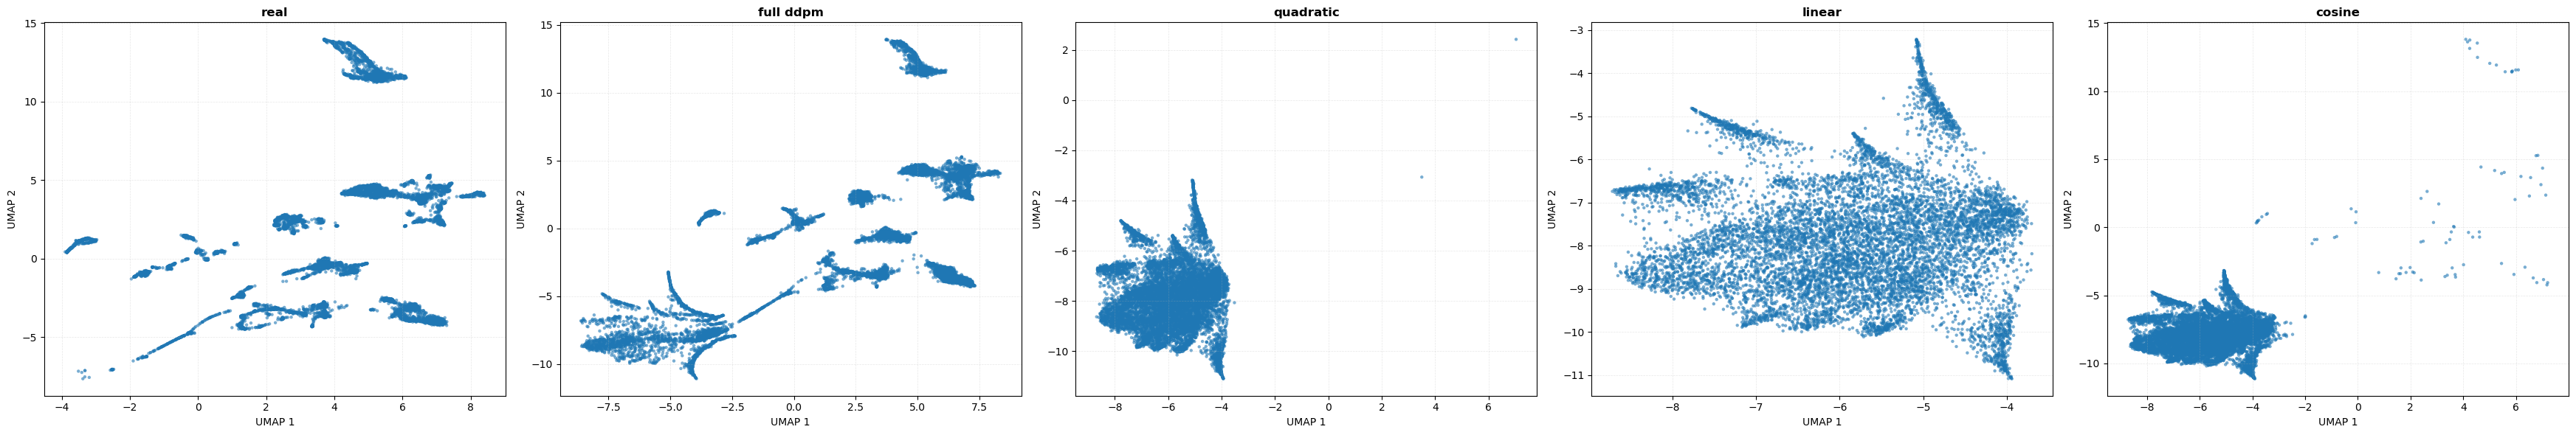

In [31]:
compare_umap([scaled_encoded_10k, 
              standardized_latent_ddpm_samples, 
              standardized_latent_samples_quadratic, 
              standardized_latent_samples_linear, 
              standardized_latent_samples_cosine],
             title_list=["real", "full ddpm", "quadratic", "linear", "cosine"])

Performing UMAP on combined dataset (40000 samples, 128 features) across 4 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 0.99744487, 11.958984  ],
         [ 3.8595765 , 10.417921  ],
         [-0.46771362,  3.415117  ],
         ...,
         [ 2.3368855 ,  8.823068  ],
         [ 0.30464664,  6.3528695 ],
         [ 4.394009  ,  2.3639007 ]], shape=(10000, 2), dtype=float32),
  array([[-4.9691777, 12.126595 ],
         [-5.4065285,  9.349058 ],
         [-3.8410168, 13.000314 ],
         ...,
         [-2.592975 , 10.197604 ],
         [-1.870401 ,  9.940474 ],
         [-1.5669609,  9.823364 ]], shape=(10000, 2), dtype=float32),
  array([[-3.6514242, 11.322669 ],
         [-3.896776 , 12.015928 ],
         [-4.5151043, 11.699761 ],
         ...,
         [-4.925752 , 11.428345 ],
         [-5.874853 , 11.294811 ],
         [-1.5336453, 13.624257 ]], shape=(10000, 2), dtype=float32),
  array([[-5.4289093, 10.7877035],
         [-4.3903475,  9.752317 ],
         [-5.9784875, 11.513869 ],
         ...,
         [-1.6796677, 12.493349 ],
         [-3.0518324, 10.824174 ],
         [-1.9703583, 

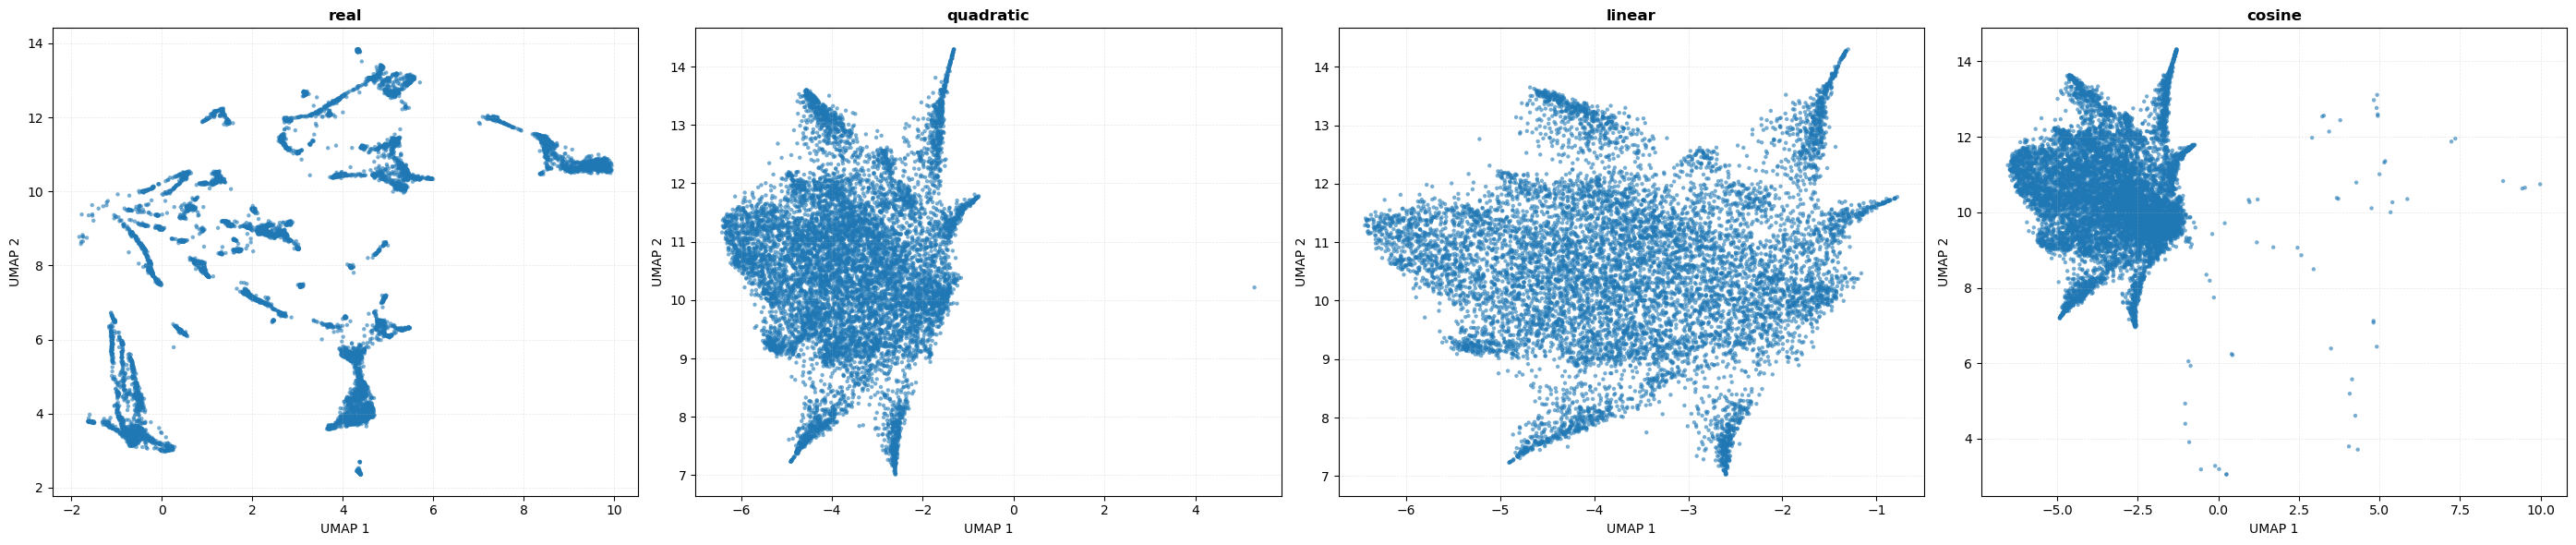

In [34]:
compare_umap([scaled_encoded_10k, standardized_latent_samples_quadratic, standardized_latent_samples_linear, standardized_latent_samples_cosine],
             title_list=["real", "quadratic", "linear", "cosine"])

Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...
Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...
Performing UMAP on combined dataset (20000 samples, 128 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 0.8098045 , -2.3903577 ],
         [ 2.3511238 , -3.23875   ],
         [-4.450153  ,  6.438301  ],
         ...,
         [ 3.0438693 , -7.231918  ],
         [-5.6559544 , -3.0405176 ],
         [ 1.9264241 ,  0.83763784]], shape=(10000, 2), dtype=float32),
  array([[  0.96953994, -11.443042  ],
         [  0.7567851 , -10.724752  ],
         [  1.7376093 , -11.870635  ],
         ...,
         [ -2.4582977 , -10.679557  ],
         [ -0.8488758 ,  -8.997344  ],
         [  0.83844477,  -9.063109  ]], shape=(10000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

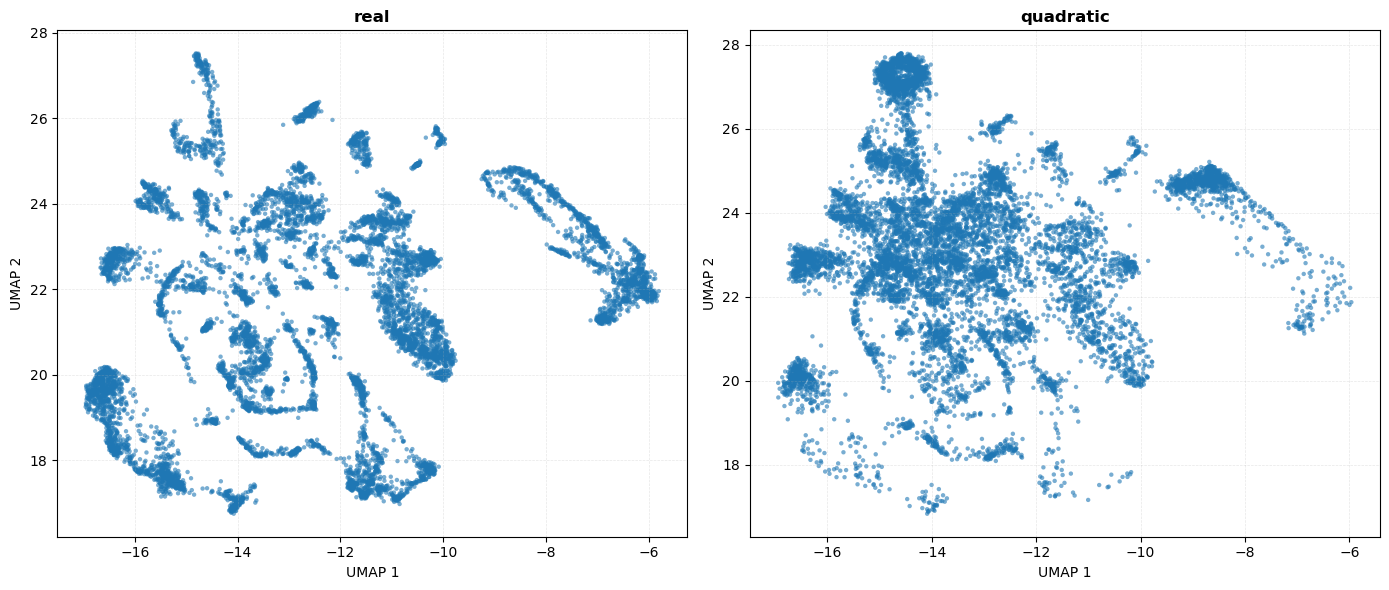

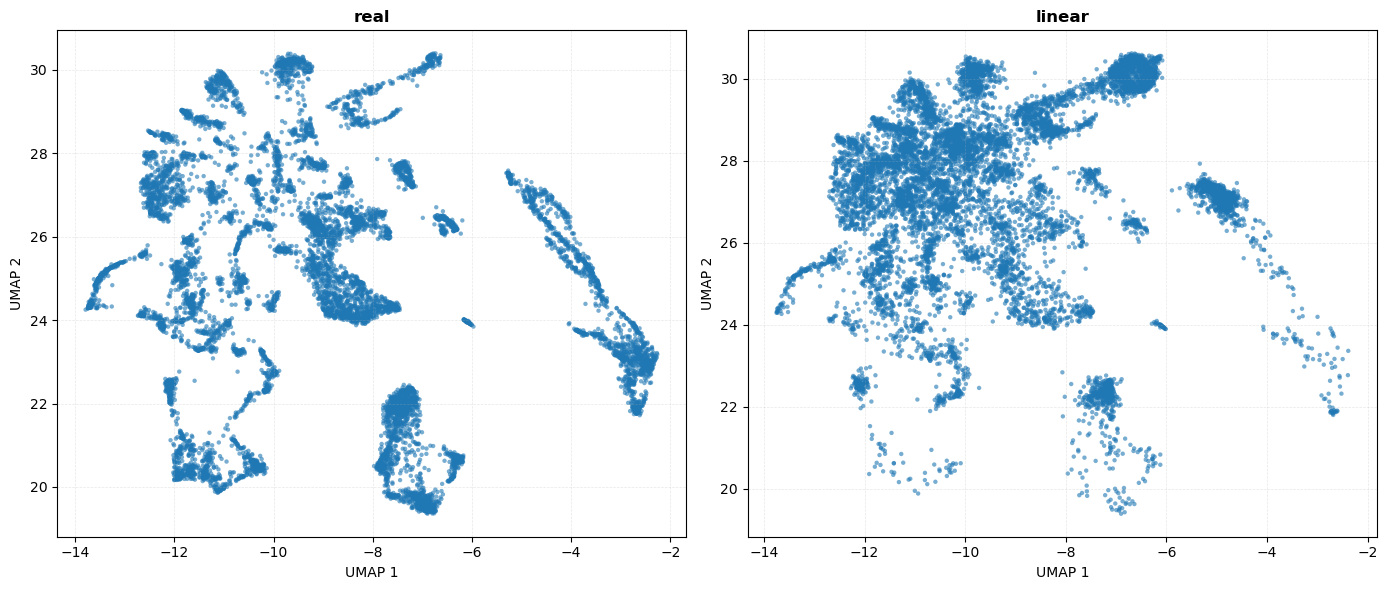

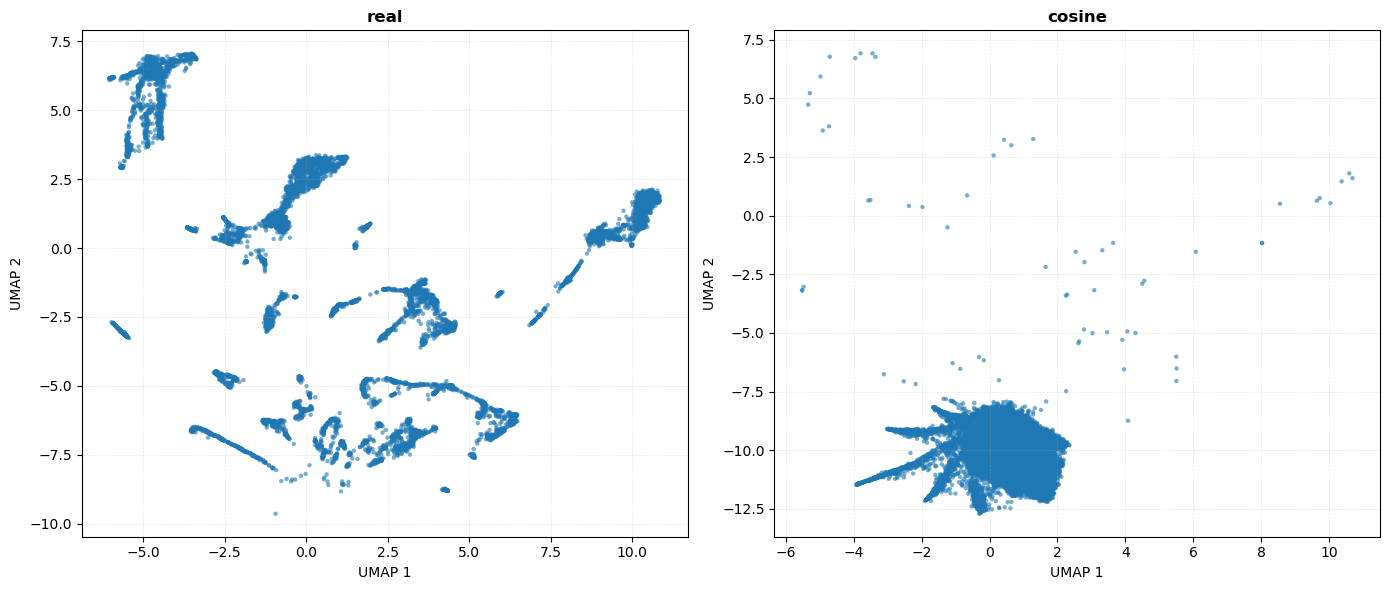

In [36]:
compare_umap([scaled_encoded_10k, standardized_latent_samples_quadratic],
             title_list=["real", "quadratic"])
compare_umap([scaled_encoded_10k, standardized_latent_samples_linear],
             title_list=["real", "linear"])
compare_umap([scaled_encoded_10k, standardized_latent_samples_cosine],
             title_list=["real", "cosine"])


Performing UMAP on combined dataset (30000 samples, 18996 features) across 3 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 2.1099577, -1.6738323],
         [-2.6100373,  7.1363015],
         [ 6.2544975, -8.118281 ],
         ...,
         [ 2.1188066, -3.5802228],
         [14.028922 ,  1.3301331],
         [ 6.4811716, -7.9875474]], shape=(10000, 2), dtype=float32),
  array([[  7.172798 , -10.416492 ],
         [  7.4518504, -10.048067 ],
         [ 13.395051 ,   0.1991443],
         ...,
         [  3.929781 ,  -5.622767 ],
         [  4.159765 , -11.637815 ],
         [ 13.724434 ,  -1.3358217]], shape=(10000, 2), dtype=float32),
  array([[ 1.6992078, -2.8722737],
         [-7.7245874,  6.0465465],
         [ 1.3775685, 12.480149 ],
         ...,
         [-9.044041 ,  8.530953 ],
         [ 0.3048169, 11.8284   ],
         [-3.0198464,  6.9712915]], shape=(10000, 2), dtype=float32)],
 <Figure size 2100x600 with 3 Axes>)

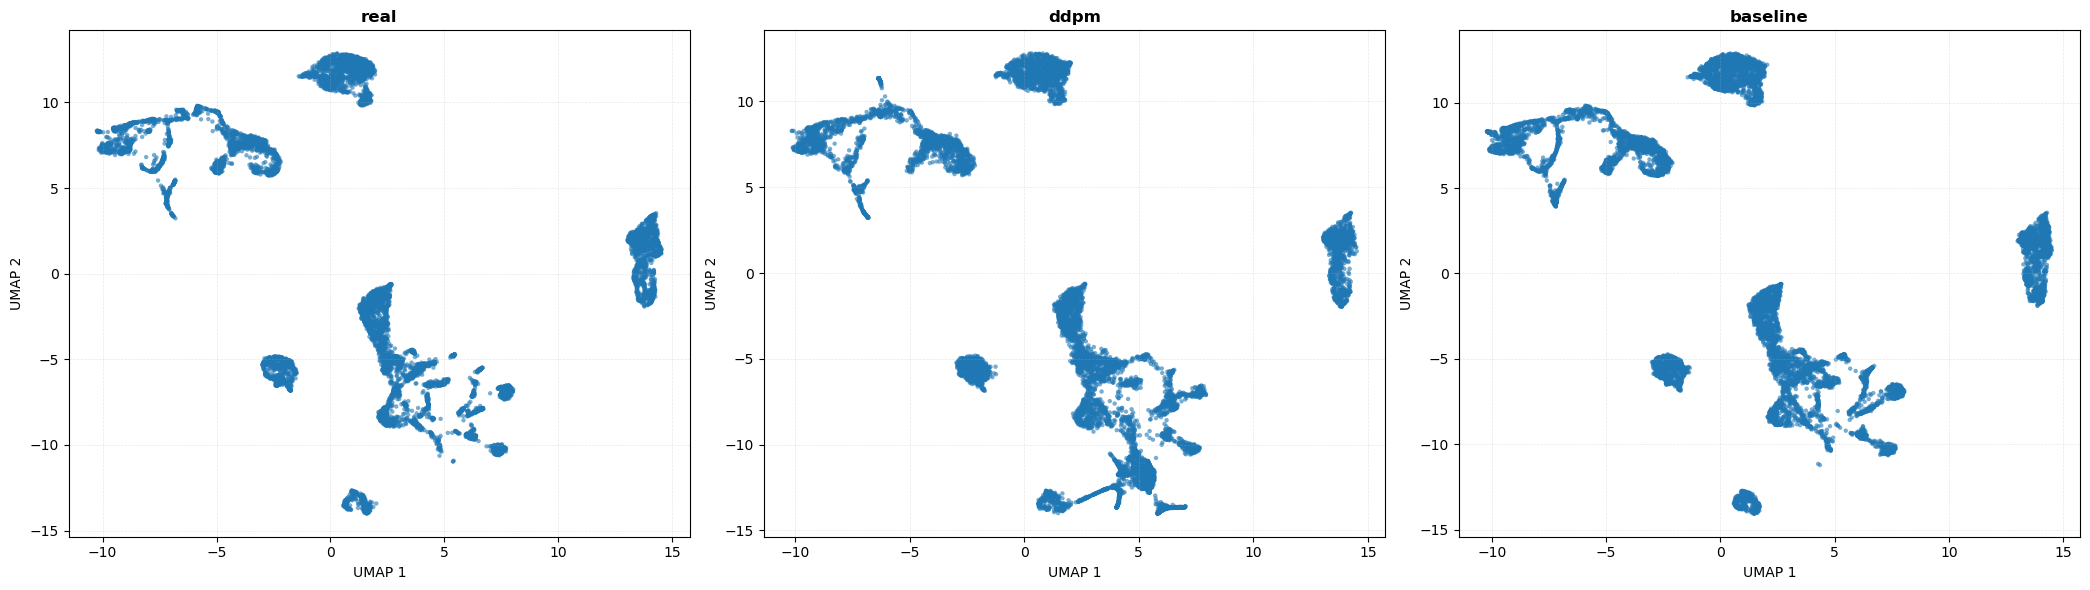

In [32]:
invered_ddpm_samples = standard_scaler.inverse_transform(standardized_latent_ddpm_samples)

with torch.no_grad():
    decoded_ddpm_samples = ae.decode(torch.tensor(invered_ddpm_samples).to(device=device, dtype=torch.float32))
    
compare_umap([muris_10k, decoded_ddpm_samples, samples_baseline],
             title_list=["real", "ddpm", "baseline"])